# 07. Model Evaluation

This notebook compares the trained models in detail and selects the best one for groundwater level prediction.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## Load Feature-Engineered Dataset

We reuse the engineered dataset created in the earlier notebooks.

In [2]:
candidate_paths = [
    Path("../datasets/groundwater_feature_engineered.csv"),
    Path("datasets/groundwater_feature_engineered.csv"),
    Path("groundwater_feature_engineered.csv")
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("groundwater_feature_engineered.csv not found in expected paths.")

df = pd.read_csv(dataset_path, parse_dates=["Data Acquisition Time"])

print(f"Dataset path: {dataset_path.resolve()}")
print(f"Shape: {df.shape}")
print(f"Stations: {df['Station'].nunique()}")
df.head()

Dataset path: /content/groundwater_feature_engineered.csv
Shape: (69404, 25)
Stations: 18


,Station,Data Acquisition Time,Latitude,Longitude,Groundwater Level Telemetry 6 Hourly (meter),RL_MSL,time_diff,Year,Month,Day,...,Lag_1,Lag_4,Lag_28,RollingMean_4,RollingStd_4,Hour_sin,Hour_cos,Month_sin,Month_cos,Station_ID
0,Adakamaranahalli,2021-10-06 00:00:00,13.07,77.45,-22.50,849.0,1 days 06:00:00,2021,10,6,...,-22.71,-22.34,-22.51,-22.8625,0.419235,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0
1,Adakamaranahalli,2021-10-06 06:00:00,13.07,77.45,-22.83,849.0,0 days 06:00:00,2021,10,6,...,-22.50,-23.16,-22.87,-22.9025,0.355563,1.000000e+00,6.123234e-17,-1.0,-1.836970e-16,0
2,Adakamaranahalli,2021-10-06 12:00:00,13.07,77.45,-22.88,849.0,0 days 06:00:00,2021,10,6,...,-22.83,-23.24,-23.23,-22.8200,0.311448,1.224647e-16,-1.000000e+00,-1.0,-1.836970e-16,0
3,Adakamaranahalli,2021-10-06 18:00:00,13.07,77.45,-22.52,849.0,0 days 06:00:00,2021,10,6,...,-22.88,-22.71,-22.66,-22.7300,0.169115,-1.000000e+00,-1.836970e-16,-1.0,-1.836970e-16,0
4,Adakamaranahalli,2021-10-07 00:00:00,13.07,77.45,-22.35,849.0,0 days 06:00:00,2021,10,7,...,-22.52,-22.50,-22.46,-22.6825,0.200395,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0


## Prepare Features and Target

The same feature columns from notebook 06 are used to keep comparison fair.

In [3]:
target = "Groundwater Level Telemetry 6 Hourly (meter)"

features = [
    "Latitude", "Longitude", "RL_MSL",
    "Year", "Month", "Day", "Hour",
    "DayOfWeek", "WeekOfYear", "Quarter", "IsWeekend",
    "Lag_1", "Lag_4", "Lag_28",
    "RollingMean_4", "RollingStd_4",
    "Hour_sin", "Hour_cos", "Month_sin", "Month_cos",
    "Station_ID"
]

X = df[features]
y = df[target]

print("Number of features:", len(features))

Number of features: 21


## Chronological Train-Test Split

We use the same 80-20 chronological split used in previous notebooks.

In [4]:
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[features]
X_test = test_df[features]
y_train = train_df[target]
y_test = test_df[target]

print(f"Train rows: {len(train_df)}")
print(f"Test rows : {len(test_df)}")
print("Train period:", train_df["Data Acquisition Time"].min(), "to", train_df["Data Acquisition Time"].max())
print("Test period :", test_df["Data Acquisition Time"].min(), "to", test_df["Data Acquisition Time"].max())

Train rows: 55523
Test rows : 13881
Train period: 2021-10-06 00:00:00 to 2025-12-30 18:00:00
Test period : 2021-10-07 00:00:00 to 2025-12-30 18:00:00


## Load Saved Models (If Available) or Train Again

If model files exist, they are loaded. Otherwise, models are trained with the same settings as notebook 06.

In [5]:
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

model_specs = {
    "Linear Regression": {
        "path": model_dir / "linear_regression.pkl",
        "model": LinearRegression()
    },
    "Random Forest": {
        "path": model_dir / "random_forest.pkl",
        "model": RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    },
    "XGBoost": {
        "path": model_dir / "xgboost.pkl",
        "model": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    }
}

trained_models = {}
predictions = {}
results = []

for model_name, spec in model_specs.items():
    model_path = spec["path"]

    if model_path.exists():
        model = joblib.load(model_path)
        source = "loaded"
    else:
        model = spec["model"]
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        source = "trained"

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    results.append({
        "Model": model_name,
        "Source": source,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

comparison_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
comparison_df

,Model,Source,MAE,RMSE,R²
0,Linear Regression,trained,2.588731,6.143446,0.877659
1,XGBoost,trained,3.419760,7.443628,0.820396
2,Random Forest,trained,4.064179,8.026415,0.791172


## Metric Comparison Table

In [6]:
comparison_df.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R²": "{:.4f}"})

,Model,Source,MAE,RMSE,R²
0,Linear Regression,trained,2.5887,6.1434,0.8777
1,XGBoost,trained,3.4198,7.4436,0.8204
2,Random Forest,trained,4.0642,8.0264,0.7912


## Visual Comparison of MAE, RMSE and R²

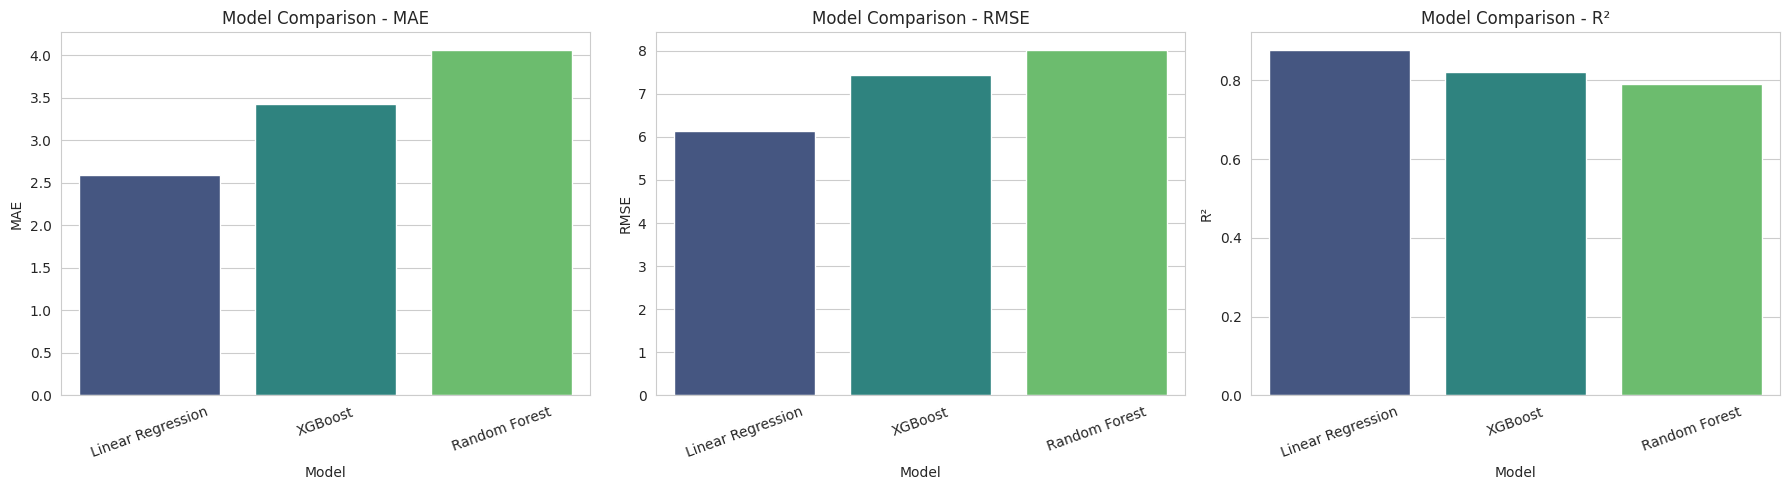

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["MAE", "RMSE", "R²"]
for i, metric in enumerate(metrics):
    sns.barplot(data=comparison_df, x="Model", y=metric, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Model Comparison - {metric}")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Residual Distribution

Residual = actual value - predicted value

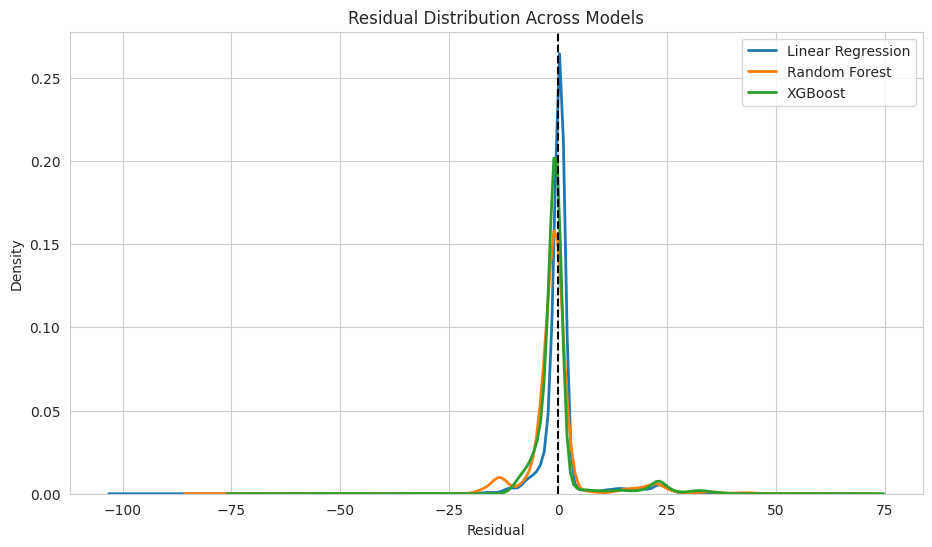

In [8]:
residual_df = pd.DataFrame({"Actual": y_test.values})

for model_name, y_pred in predictions.items():
    residual_df[model_name] = y_test.values - y_pred

plt.figure(figsize=(11, 6))
for model_name in predictions.keys():
    sns.kdeplot(residual_df[model_name], label=model_name, fill=False, linewidth=2)

plt.axvline(0, color="black", linestyle="--")
plt.title("Residual Distribution Across Models")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend()
plt.show()

## Error Analysis by Station

This helps check which stations are harder to predict.

In [9]:
best_model_name = comparison_df.loc[0, "Model"]
best_pred = predictions[best_model_name]

station_error_df = pd.DataFrame({
    "Station": test_df["Station"].values,
    "Absolute_Error": np.abs(y_test.values - best_pred)
})

station_mae = (
    station_error_df
    .groupby("Station", as_index=False)["Absolute_Error"]
    .mean()
    .sort_values("Absolute_Error", ascending=False)
)

station_mae.head(10)

,Station,Absolute_Error
0,Sarjapura_1,4.443782
2,Thimmenahalli,3.557882
1,Tavarekere_1,1.023766
3,Thotagere,0.624585


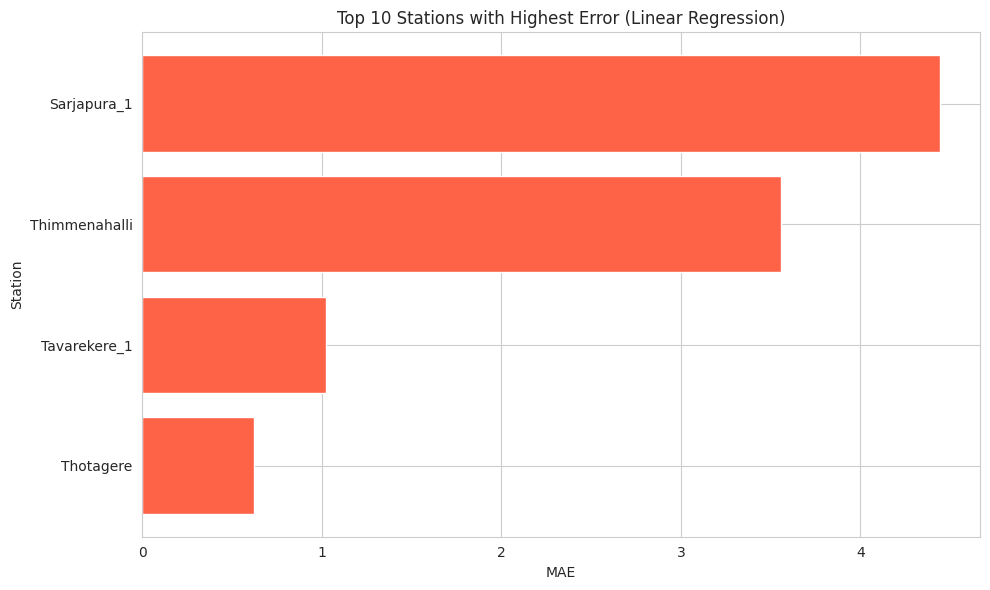

In [10]:
plt.figure(figsize=(10, 6))
plot_df = station_mae.head(10).sort_values("Absolute_Error", ascending=True)
plt.barh(plot_df["Station"], plot_df["Absolute_Error"], color="tomato")
plt.xlabel("MAE")
plt.ylabel("Station")
plt.title(f"Top 10 Stations with Highest Error ({best_model_name})")
plt.tight_layout()
plt.show()

## Error Analysis by Month (Test Period)

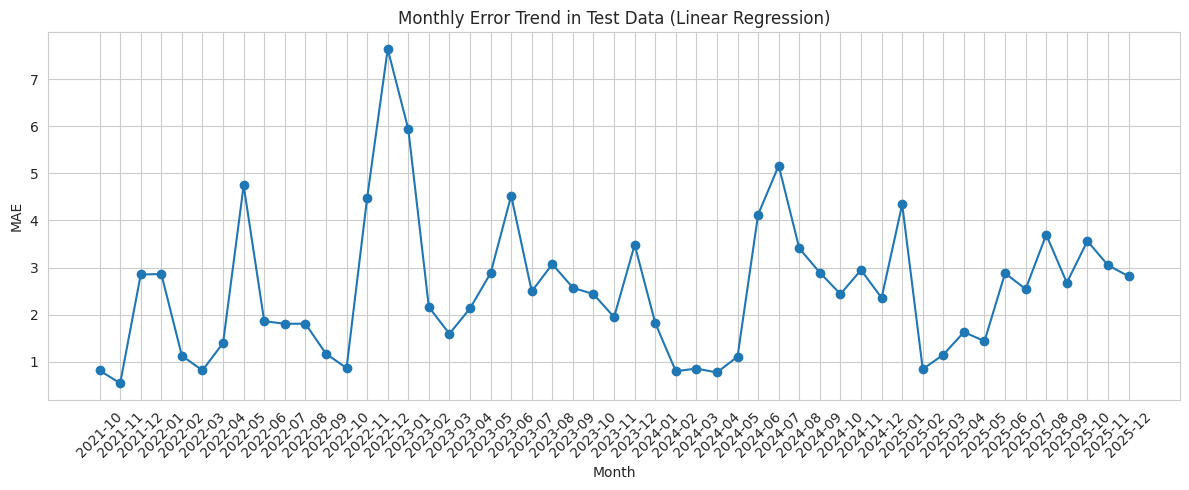

In [11]:
time_error_df = pd.DataFrame({
    "Date": test_df["Data Acquisition Time"].values,
    "Absolute_Error": np.abs(y_test.values - best_pred)
})

time_error_df["Month"] = pd.to_datetime(time_error_df["Date"]).dt.to_period("M").astype(str)
monthly_error = time_error_df.groupby("Month", as_index=False)["Absolute_Error"].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_error["Month"], monthly_error["Absolute_Error"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.xlabel("Month")
plt.title(f"Monthly Error Trend in Test Data ({best_model_name})")
plt.tight_layout()
plt.show()

## Best Model Selection

We choose the model with the lowest RMSE on the test set.

In [12]:
best_row = comparison_df.iloc[0]
print("Best model:", best_row["Model"])
print(f"MAE : {best_row['MAE']:.4f}")
print(f"RMSE: {best_row['RMSE']:.4f}")
print(f"R²  : {best_row['R²']:.4f}")

print("\nWhy this model?")
print("It gives the lowest test RMSE and strong MAE/R² compared to the other models,")
print("so overall it predicts groundwater levels more accurately on unseen data.")

Best model: Linear Regression
MAE : 2.5887
RMSE: 6.1434
R²  : 0.8777

Why this model?
It gives the lowest test RMSE and strong MAE/R² compared to the other models,
so overall it predicts groundwater levels more accurately on unseen data.
